# Quincy Cobb (qcc75): COE 311K Final Project


## Part 1/3:
### Section 1:
For this project, I have selected Option A: Spring-Mass System (Mechanical Oscillations). Specifically, I am modeling a "Quarter-Car Suspension Model" of my car, a 2015 Honda Accord's suspension system, as it hits a speed bump. 

The governing second-order ODE is:
m(y'') + c(y') + ky = 0

To solve this numerically, we convert it to a system of first-order ODEs where y1 is position and y2 is velocity:
y1' = y2
y2' = -(c/m)y2 - (k/m)y1

In [1]:
# Section 2
import numpy as np
import matplotlib.pyplot as plt

m = 370.0      # Mass of one quarter of a 2015 Honda Accord LX (kg) found on hondanews.com
k = 30000.0    # Estimated spring constant for passenger car (N/m) found on calltogrid.com
c = 1999.0     # Damping coefficient for a damping ratio of 0.3 (N*s/m) calculated from m and k values above (c= 2(.3)(sqrt(30000*370))

# initial conditions of dropping off a 10cm (0.1m) curb from rest
y0 = np.array([0.1, 0.0]) # [initial position (y(0)), initial velocity (y'(0))]

# simulation time parameters
t_start = 0.0
t_end = 2.0    

def accord_suspension(t, y):
    y1 = y[0] # position
    y2 = y[1] # velocity
    dy1_dt = y2
    dy2_dt = -(c / m) * y2 - (k / m) * y1
    
    return np.array([dy1_dt, dy2_dt])

### Section 2: Parameter Research and Justification
The mass of a Honda Accord LX in 2025 is about 1480 kg, so one quarter is 370 kg. (https://hondanews.com/en-US/honda-automobiles/releases/release-865718e7c6694e78ac6ae05df6233bcd-2015-accord-sedan-specifcations-features)
The estimated spring constant for a passenger car is about 30000 N/m . (https://calltogrid.com/spring-rate-guide-calculator/)
To calculate the damping coefficient, you have to use the previous m and k values, and use the damping ratio using this equation (c = 2(.3)(sqrt(30000*370)). 
We will be calculating what happens when a Honda Accord is in motion and comes along a 10cm speed bump and need all of these values to calculate different models.

### Section 3: Numerical Methods Implementation
The Euler's method is a basic calculation where it calculates the next point by assuming the rate of change stays exactly the same across a time step. 
The Runge-Kutta 4 method is a more advanced method that calculates the next point by checking the rate of change at four different spots within a single time step and averaging them.

In [2]:
# Section 3: Numerical Methods
def euler_method(f, Y0, t_start, t_end, h):
    """Integrates using Forward Euler Method."""
    t = np.arange(t_start, t_end + h, h)
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    
    for i in range(1, len(t)):
        Y[i] = Y[i-1] + h * f(t[i-1], Y[i-1])
        
    return t, Y

def rk4_method(f, Y0, t_start, t_end, h):
    """Integrates using 4th Order Runge-Kutta Method."""
    t = np.arange(t_start, t_end + h, h)
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    
    for i in range(1, len(t)):
        k1 = f(t[i-1], Y[i-1])
        k2 = f(t[i-1] + h/2.0, Y[i-1] + (h/2.0) * k1)
        k3 = f(t[i-1] + h/2.0, Y[i-1] + (h/2.0) * k2)
        k4 = f(t[i-1] + h, Y[i-1] + h * k3)
        
        Y[i] = Y[i-1] + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
    return t, Y

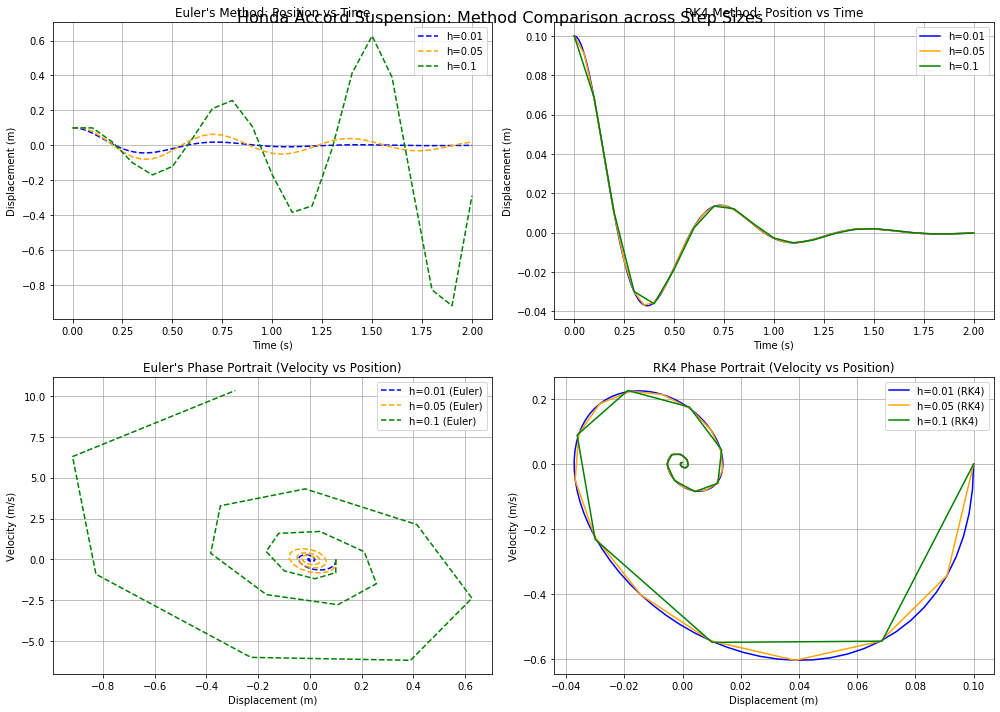

In [3]:
# Section 4
step_sizes = [0.01, 0.05, 0.1]
colors = ['blue', 'orange', 'green']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Honda Accord Suspension: Method Comparison across Step Sizes', fontsize=16)

for h, color in zip(step_sizes, colors):

    t_eul, Y_eul = euler_method(accord_suspension, y0, t_start, t_end, h)
    t_rk4, Y_rk4 = rk4_method(accord_suspension, y0, t_start, t_end, h)
    
    # euler plot 
    axs[0, 0].plot(t_eul, Y_eul[:, 0], label=f'h={h}', color=color, linestyle='--')
    # rk4 plot
    axs[0, 1].plot(t_rk4, Y_rk4[:, 0], label=f'h={h}', color=color)
    # phase position
    axs[1, 0].plot(Y_eul[:, 0], Y_eul[:, 1], label=f'h={h} (Euler)', color=color, linestyle='--')
    axs[1, 1].plot(Y_rk4[:, 0], Y_rk4[:, 1], label=f'h={h} (RK4)', color=color)

axs[0, 0].set_title("Euler's Method: Position vs Time")
axs[0, 0].set_xlabel("Time (s)")
axs[0, 0].set_ylabel("Displacement (m)")
axs[0, 0].legend()
axs[0, 0].grid()

axs[0, 1].set_title("RK4 Method: Position vs Time")
axs[0, 1].set_xlabel("Time (s)")
axs[0, 1].set_ylabel("Displacement (m)")
axs[0, 1].legend()
axs[0, 1].grid()

axs[1, 0].set_title("Euler's Phase Portrait (Velocity vs Position)")
axs[1, 0].set_xlabel("Displacement (m)")
axs[1, 0].set_ylabel("Velocity (m/s)")
axs[1, 0].legend()
axs[1, 0].grid()

axs[1, 1].set_title("RK4 Phase Portrait (Velocity vs Position)")
axs[1, 1].set_xlabel("Displacement (m)")
axs[1, 1].set_ylabel("Velocity (m/s)")
axs[1, 1].legend()
axs[1, 1].grid()

plt.tight_layout()
plt.show()

### Section 4: Discussion of visual differences between methods
#### Displacement vs. Time (Top Plots)
Euler's Method (Top Left): The largest step size of h=0.1 (green dashed line) fails to simulate a realistic Honda Accord suspension. Instead of settling down to zero, the waves grow significantly larger over time with increasing step sizes. This shows the method becoming numerically unstable. 

RK4 Method (Top Right): All three step sizes smoothly damp down toward zero, showing the system is stabilizing properly.
#### Phase Portraits - Velocity vs. Position (Bottom Plots)
Euler's Method (Bottom Left): A car's suspension losing energy should spiral inward toward the center. The h=0.1 line spirals drastically outward into a jagged shape. This is visual proof that Euler's method's math errors cause it to blow up.
RK4 Method (Bottom Right): All three lines correctly spiral inward, showing the suspension settling to a stop.
#### From these graphs, you can take away that Euler's method blows up and becomes completely unstable at a step size of 0.1. Meanwhile, the RK4 method handles that same step size perfectly, accurately capturing the suspension without spiraling out of control.

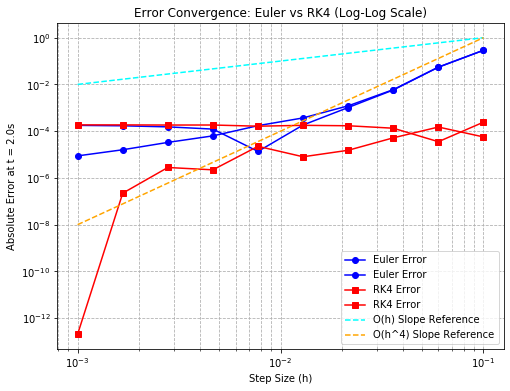

In [4]:
# section 5
# analytical solution
alpha = c / (2 * m)
omega_d = np.sqrt(k / m - alpha**2)

def exact_solution(t):
    return np.exp(-alpha * t) * (y0 * np.cos(omega_d * t) + (alpha * y0 / omega_d) * np.sin(omega_d * t))

# error analysis
h_vals = np.logspace(-3, -1, 10)
error_euler = []
error_rk4 = []

target_time = 2.0
y_exact_target = exact_solution(target_time)

for h in h_vals:
    _, Y_eul = euler_method(accord_suspension, y0, 0, target_time, h)
    _, Y_rk4 = rk4_method(accord_suspension, y0, 0, target_time, h)
    
    error_euler.append(np.abs(Y_eul[-1, 0] - y_exact_target)) ## calculate absolute error
    error_rk4.append(np.abs(Y_rk4[-1, 0] - y_exact_target))

# Log-Log Error Plot
plt.figure(figsize=(8, 6))
plt.loglog(h_vals, error_euler, 'o-', label="Euler Error", color='blue')
plt.loglog(h_vals, error_rk4, 's-', label="RK4 Error", color='red')
plt.loglog(h_vals, 1e1 * h_vals**1, '--', color='cyan', label="O(h) Slope Reference")
plt.loglog(h_vals, 1e4 * h_vals**4, '--', color='orange', label="O(h^4) Slope Reference")

plt.title("Error Convergence: Euler vs RK4 (Log-Log Scale)")
plt.xlabel("Step Size (h)")
plt.ylabel("Absolute Error at t = 2.0s")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

### Section 5: Discussion of Stable vs. Unstable Behavior
When the simulation is stable, it means the math is working correctly without small errors to make sure the numbers aren't extraneous and give the right answer. RK4 does this very well, but Euler only does it well only if the time steps super tiny. In real life, a stable graph looks exactly like how car suspension works. If I hit a bump in my Honda Accord, the shock absorbs the energy, the bouncing gets smaller, and eventually, the car rides smoothly again.
Now, contrasting when the simulation is unstable, it is taking step sizes that are too big for the computer to handle, making the math essentially break. The small errors pile up and multiply on every single step to make the numbers go crazy and spiral out of control. It doesn't completely translate to a real-world physical application, though, because the math errors are piling up, and the simulation is adding fake energy out of nowhere. If a real car acted like this, hitting a bump would make it bounce higher and higher every time until the car completely fell apart.

### Section 6: Conclusions
*Which method performed better?:* The 4th-Order Runge-Kutta (RK4) method outperformed Euler's Forward method in modeling my Honda Accord's suspension. Euler's method quickly became unstable and generated non-physical ans extraneous results, while the RK4 remained completely stable and highly accurate all throughout.

*Computational Cost vs. Accuracy Tradeoff:* Euler's method is computationally cheap, requiring only one function evaluation per time step, but its O(h) accuracy means we need extremely small step sizes to get a usable result. RK4 requires four function evaluations per time step, which makes it roughly four times as expensive per step, but its O(h^4) accuracy allows us to take much larger steps. Overall, RK4 is more efficient because the succint accuracy easily outweighs the extra computations per step.

*Practical Recommendation?:* If I were programming an onboard computer for a car's active suspension system, I would only recommend RK4. Euler's method is too risky and unreliable for mechanical systems with low damping, as any error in the computer's calculation could cause the software to assume the car is experiencing unnatural forces.

*Lessons Learned:* Through this project, I learned how to translate a theoretical, second-order engineering problem into a system of first-order ODEs that a computer can solve. I also learned that visualizing stability limits and tracking the convergence rates on a log-log plot provides definitive, mathematical proof of why higher-order solvers like RK4 are the industry standard for physical simulations.

## Part 2/3

### Section 1: Introduction & System Selection
I chose Mechanical System with High Damping (Option D).This models an overdamped spring-mass system where the mass is assumed to be extremely small, allowing us to treat it as a first-order system.
#### The Governing ODE: *dx/dt = -(k/c)x + (1/c)(F(t))*

*The Physical Meaning of the Variables:*
x: system displacement
k: spring constant
c: damping coefficent
F(t): externally applied function

*Parameters:*
(k/c): 5000 s^-1
F(t): 10sin(t) N

*Why this system is stiff:*
A system is considered "stiff" when it mixes extremely fast and very slow changes. In this case, the system reacts almost instantly (0.0002 seconds), but the outside force takes several seconds to change. This massive gap in speeds makes it very difficult for standard computer programs to solve the math efficiently.

*System in Practice:*
Highly damped mechanical systems appear in many real-world applications such as shock absorbers, vibration isolation devices, and seismic damping systems. Accurately and efficiently simulating these systems is important for predicting the structures response and ensuring safe, reliable designs. 

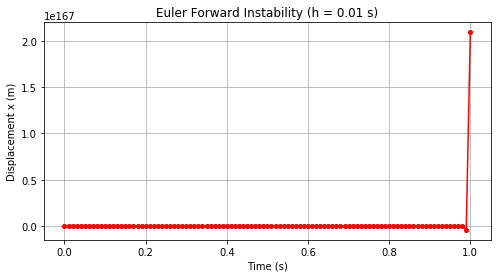

In [5]:
# Section 2:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
lam = 5000.0  # High damping coefficient (stiffness)
x0 = 0.02     # Initial displacement
t0, tf = 0.0, 1.0

def g(t):
    """Slowly varying external force / equilibrium point."""
    return 0.01 * np.sin(2 * t)

def euler_forward(h):
    """Explicit Euler Forward implementation."""
    t = np.arange(t0, tf + h, h)
    x = np.zeros_like(t)
    x[0] = x0
    
    for n in range(len(t) - 1):
        x[n+1] = x[n] + h * (-lam * (x[n] - g(t[n])))
    return t, x

t_fe, x_fe = euler_forward(h=0.01)

plt.figure(figsize=(8, 4))
plt.plot(t_fe, x_fe, 'r-o', markersize=4)
plt.title("Euler Forward Instability (h = 0.01 s)")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x (m)")
plt.grid(True)
plt.show()

### Section 3: Mathematical Setup

The governing equation for this project is

\[
\frac{dx}{dt} = -5000x + 0.002\sin(t),
\quad x(0) = 1.
\]

To solve this stiff ODE, Euler’s Backward (implicit Euler) method is used:

\[
x_{n+1} = x_n + h\,f(t_{n+1}, x_{n+1}).
\]

Substituting the specific function \( f(t,x) \) gives

\[
x_{n+1} = x_n + h\left(-5000x_{n+1} + 0.002\sin(t_{n+1})\right).
\]

This equation is implicit since \( x_{n+1} \) appears on both sides.  
The residual function is defined as

\[
R(x_{n+1}) = x_{n+1} - x_n - h\left(-5000x_{n+1} + 0.002\sin(t_{n+1})\right).
\]

Newton–Raphson iteration is used to solve \( R(x_{n+1}) = 0 \).  
The derivative of the residual is

\[
\frac{dR}{dx_{n+1}} = 1 + 5000h.
\]

Since the equation is linear, this derivative is constant.  
The Newton–Raphson update formula is

\[
x_{n+1}^{(k+1)} = x_{n+1}^{(k)} - \frac{R(x_{n+1}^{(k)})}{1 + 5000h}.
\]

An explicit Euler step is used as the initial guess at each time step.
(used Microsoft Copilot to try to properly format for markdown)

In [6]:
# section 4

def residual(x_new, x_old, t_new, h, lam):
    """Residual function for Backward Euler."""
    return x_new - x_old + h * lam * (x_new - g(t_new))

def newton_raphson(x_guess, x_old, t_new, h, lam, tol=1e-10, max_iter=20):
    """Newton-Raphson root-finding algorithm."""
    dR = 1 + h * lam 
    x = x_guess
    
    for k in range(max_iter):
        R = residual(x, x_old, t_new, h, lam)
        x_new = x - R / dR
  
        if abs(x_new - x) < tol:
            return x_new, k + 1
            
        x = x_new
        
    raise RuntimeError("Newton-Raphson did not converge within maximum iterations")

def euler_backward(t0, tf, x0, h, lam):
    """Implicit Euler Backward method utilizing Newton-Raphson."""
    t = np.arange(t0, tf + h, h)
    x = np.zeros_like(t)
    iters = np.zeros_like(t)
    
    x[0] = x0
    
    for n in range(len(t) - 1):
        x_guess = x[n] 
        x[n+1], iters[n+1] = newton_raphson(x_guess, x[n], t[n+1], h, lam)
        
    return t, x, iters

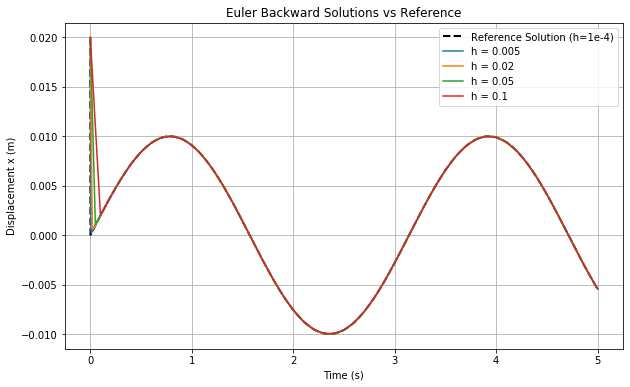

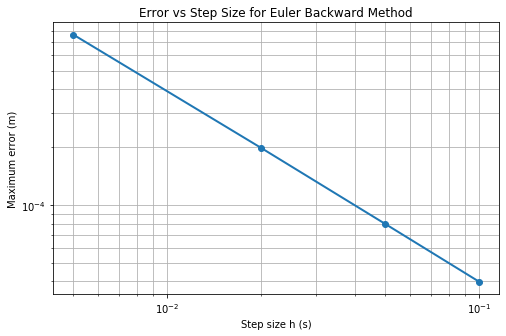

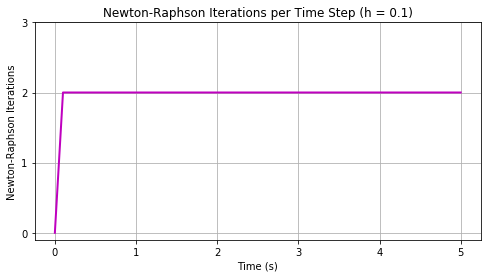

Average Newton iterations (h = 0.1): 1.96
Maximum Newton iterations (h = 0.1): 2.0


In [7]:
# section 5
tf = 5.0
hs = [0.005, 0.02, 0.05, 0.1]

# 5.1 Reference (High-Accuracy) Solution
h_ref = 1e-4
t_ref, x_ref, _ = euler_backward(t0, tf, x0, h_ref, lam)

# 5.2 Euler Backward Solutions for different step sizes
solutions = {}
for h in hs:
    t, x, iters = euler_backward(t0, tf, x0, h, lam)
    solutions[h] = {
        "t": t,
        "x": x,
        "iters": iters
    }

# 5.3 Solution Comparison Plot
plt.figure(figsize=(10, 6))
plt.plot(t_ref, x_ref, 'k--', linewidth=2, label="Reference Solution (h=1e-4)")

for h in hs:
    plt.plot(solutions[h]["t"], solutions[h]["x"], label=f"h = {h}")

plt.title("Euler Backward Solutions vs Reference")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x (m)")
plt.legend()
plt.grid(True)
plt.show()

# 5.4 Error vs Step Size
errors = []
for h in hs:
    t = solutions[h]["t"]
    x = solutions[h]["x"]
    x_ref_interp = np.interp(t, t_ref, x_ref)
    errors.append(np.max(np.abs(x - x_ref_interp)))         

plt.figure(figsize=(8, 5))
plt.loglog(hs, errors, 'o-', linewidth=2)
plt.xlabel("Step size h (s)")
plt.ylabel("Maximum error (m)")
plt.title("Error vs Step Size for Euler Backward Method")
plt.grid(True, which="both")
plt.show()

# 5.5 Newton-Raphson Convergence
plt.figure(figsize=(8, 4))
plt.plot(solutions[0.1]["t"], solutions[0.1]["iters"], 'm-', linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Newton-Raphson Iterations")
plt.title("Newton-Raphson Iterations per Time Step (h = 0.1)")
plt.yticks([0, 1, 2, 3])
plt.grid(True)
plt.show()

print(f"Average Newton iterations (h = 0.1): {np.mean(solutions[0.1]['iters']):.2f}")
print(f"Maximum Newton iterations (h = 0.1): {np.max(solutions[0.1]['iters'])}")


Performance Table:
 Step size h (s)  Number of steps  Average NR iterations  Total NR iterations
           0.005             1000               1.998002               2000.0
           0.020              250               1.992032                500.0
           0.050              100               1.980198                200.0
           0.100               50               1.960784                100.0

Euler Forward Stability & Cost:
  Maximum stable step size: h < 4.00e-04
  Steps required for 5 seconds: 13,888


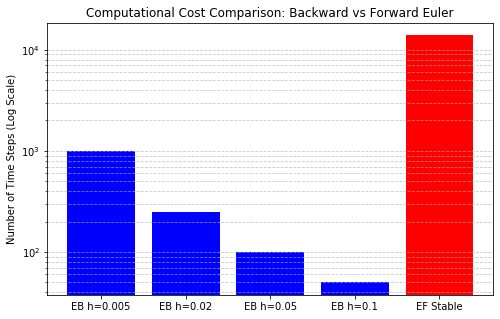

In [8]:
# Section 6: Performance Analysis
import pandas as pd

performance_data = []

for h in hs:
    t = solutions[h]["t"]
    iters = solutions[h]["iters"]
    
    n_steps = len(t) - 1
    avg_iters = np.mean(iters)
    total_iters = np.sum(iters)
    
    performance_data.append([h, n_steps, avg_iters, total_iters])

# 6.2 Performance Table
df_performance = pd.DataFrame(
    performance_data,
    columns=[
        "Step size h (s)",
        "Number of steps",
        "Average NR iterations",
        "Total NR iterations"
    ]
)

print("\nPerformance Table:")
print(df_performance.to_string(index=False))

# 6.3 Euler Forward Cost
h_fe_max = 2.0 / lam
h_fe_stable = h_fe_max * 0.9 
n_steps_fe = int(tf / h_fe_stable)

print("\nEuler Forward Stability & Cost:")
print(f"  Maximum stable step size: h < {h_fe_max:.2e}")
print(f"  Steps required for 5 seconds: {n_steps_fe:,}")

# 6.4 Cost Comparison Plot
labels = [f"EB h={h}" for h in hs] + ["EF Stable"]
costs = [row[1] for row in performance_data] + [n_steps_fe]

plt.figure(figsize=(8, 5))
plt.bar(labels, costs, color=['blue', 'blue', 'blue', 'blue', 'red'])
plt.yscale('log') 
plt.ylabel("Number of Time Steps (Log Scale)")
plt.title("Computational Cost Comparison: Backward vs Forward Euler")
plt.grid(axis="y", which="both", linestyle='--', alpha=0.7)
plt.show()

### Section 7: Conclusion

*Key Findings:*
In this project, a stiff ordinary differential equation from a highly damped mechanical system was solved using implicit numerical methods. Euler’s Forward method was shown to be impractical because it required very small time step sizes to remain stable. In contrast, Euler’s Backward method produced stable solutions even when using much larger time steps. The Newton–Raphson method converged quickly due to the linear nature of the system.

*When to use:*
Explicit methods such as Euler’s Forward are easy to implement and work well for non‑stiff problems, but they become unstable for stiff systems. Implicit methods, like Euler’s Backward, are better suited for stiff equations because they are stable for large step sizes. Even though implicit methods require solving an equation at each time step, they are more efficient overall for stiff problems.

*Challenges/What I learned*
One challenge was understanding how stiffness affects stability rather than accuracy. Implementing Newton–Raphson iteration also required careful setup of the residual function and convergence criteria. Through this project, it became clear that choosing the right numerical method is just as important as implementing it correctly. This project helped build confidence in working with implicit methods and stiff ODEs.

## Part 3/3

### Section 1:
#### System: Mechanical System with High Damping (Option D)

In Part 2, I modeled an overdamped spring-mass system acting as a shock absorber. 

*dx/dt = -5000x + 0.002sin(t)    with the initial condition x(0)= 1*

To solve this, I am using *Euler's Backward method* combined with Newton-Raphson root-finding.

*The Stiffness:* This problem is highly stiff because the natural response decays almost instantly (in about 0.2 milliseconds due to the -5000 coefficient), while the external force varies very slowly over seconds. The stiffness ratio is 5 x 10^3. If we used a standard explicit method (like Forward Euler), we would be forced to take incredibly tiny time steps just to keep the math from exploding, which is why an implicit solver is required.

In [9]:
# section 2 & 3
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    return -5000 * x + 0.002 * np.sin(t)

def g_func(x_guess, x_n, t_next, h):
    return x_guess - x_n - h * f(t_next, x_guess)

def g_prime_func(h):
    return 1.0 + 5000.0 * h

# 3.1- damped newton-raphson
def damped_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n
    damping_used = False
    
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        
        if abs(g) < tol:
            return y_guess, k, True, damping_used
            
        g_prime = g_prime_func(h)
        delta = -g / g_prime
        
        alpha = 1.0
        g_current = abs(g)
    
        for _ in range(10): 
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            
            if g_new < g_current: 
                break
                
            alpha /= 2.0
            damping_used = True 
            
        if alpha < alpha_min:
            return y_guess, k, False, damping_used
            
        y_guess = y_new
        
    return y_guess, max_iter, False, damping_used

def basic_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=20):
    """
    Undamped (classic) Newton–Raphson for implicit Euler.
    """
    y_guess = y_n

    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)

        if abs(g) < tol:
            return y_guess, k, True

        g_prime = g_prime_func(h)
        delta = -g / g_prime
        y_guess = y_guess + delta  # no damping!

    return y_guess, max_iter, False

# 3.2: error estimate
def estimate_error_step_doubling(y_n, t_n, h):
    y_full, iters_full, succ_full, damp_full = damped_newton_raphson(y_n, t_n + h, h)
    y_half_1, iters_1, succ_1, damp_1 = damped_newton_raphson(y_n, t_n + h/2.0, h/2.0)
    y_half, iters_2, succ_2, damp_2 = damped_newton_raphson(y_half_1, t_n + h, h/2.0)
    
    success = succ_full and succ_1 and succ_2
    damped = damp_full or damp_1 or damp_2
    error = abs(y_half - y_full)
    total_iters = iters_full + iters_1 + iters_2
    
    return y_full, y_half, error, total_iters, success, damped

def adjust_step_size(h_current, error, tol, safety=0.9, h_min=1e-6, h_max=1.0):
    if error < 1e-14: 
        h_new = h_current * 2.0
    else:
        h_new = h_current * np.sqrt(tol / error)
        h_new = safety * h_new 
        
    h_new = max(h_min, min(h_max, h_new))
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))
    
    return h_new

def adaptive_implicit_euler(y0, t0, t_final, h0, tol, h_min=1e-6, h_max=1.0):
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    error_history = []
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': 0,
        'damping_used_count': 0
    }
    
    t_curr = t0
    y_curr = y0
    
    while t_curr < t_final:
        if t_curr + h > t_final:
            h = t_final - t_curr
            
        y_full, y_half, error, iters, success, damped = estimate_error_step_doubling(y_curr, t_curr, h)
        
        stats['nr_iterations'] += iters
        if damped:
            stats['damping_used_count'] += 1

        if not success:
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            continue
            
        h_new = adjust_step_size(h, error, tol, safety=0.9, h_min=h_min, h_max=h_max)
        
        if error <= tol:
            t_curr += h
            y_curr = y_half
            
            t.append(t_curr)
            y.append(y_curr)
            h_history.append(h)
            error_history.append(error)
            
            stats['accepted_steps'] += 1
            h = h_new
        else:
            stats['rejected_steps'] += 1
            h = h_new 

    return np.array(t), np.array(y), np.array(h_history), np.array(error_history), stats

t0, t_final = 0.0, 10.0
y0 = 1.0
h0 = 0.1
tol = 1e-4

t_adapt, y_adapt, h_hist, err_hist, stats = adaptive_implicit_euler(y0, t0, t_final, h0, tol)

print(f"Simulation Finished.")
print(f"Accepted steps: {stats['accepted_steps']}")
print(f"Rejected steps: {stats['rejected_steps']}")
print(f"Total NR iterations: {stats['nr_iterations']}")
print(f"Times damping was required: {stats['damping_used_count']}")

print("\n=== Newton–Raphson Robustness Comparison ===")

# Intentionally large step size
h_test = 2.0
t_test = 0.0
y_test = 1.0

# Undamped Newton–Raphson
y_basic, it_basic, success_basic = basic_newton_raphson(
    y_test, t_test + h_test, h_test
)

# Damped Newton–Raphson
y_damped, it_damped, success_damped, damping_used = damped_newton_raphson(
    y_test, t_test + h_test, h_test
)

print("\nUndamped Newton–Raphson:")
print(f"  Converged: {success_basic}")
print(f"  Iterations: {it_basic}")
print(f"  Final value: {y_basic}")

print("\nDamped Newton–Raphson:")
print(f"  Converged: {success_damped}")
print(f"  Iterations: {it_damped}")
print(f"  Damping used: {damping_used}")
print(f"  Final value: {y_damped}")

Simulation Finished.
Accepted steps: 126
Rejected steps: 7
Total NR iterations: 398
Times damping was required: 0

=== Newton–Raphson Robustness Comparison ===

Undamped Newton–Raphson:
  Converged: True
  Iterations: 1
  Final value: 0.00010035368360239438

Damped Newton–Raphson:
  Converged: True
  Iterations: 1
  Damping used: False
  Final value: 0.00010035368360239438


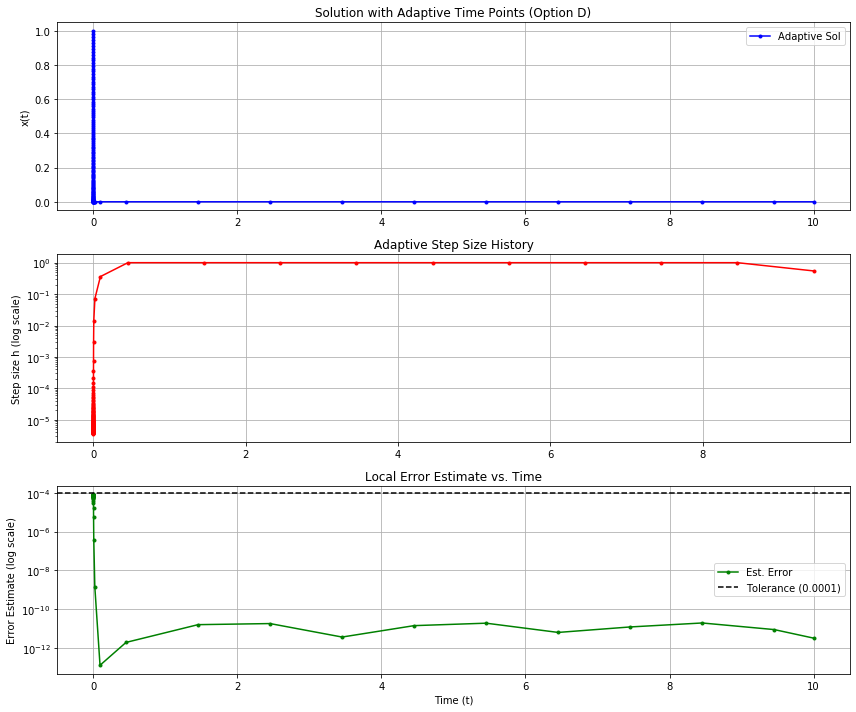

In [10]:
# section 4

plt.figure(figsize=(12, 10))

# 1. Solution Plot
plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt, 'b-o', markersize=3, label='Adaptive Sol')
plt.ylabel('x(t)')
plt.title('Solution with Adaptive Time Points (Option D)')
plt.grid(True)
plt.legend()

# 2. Step Size History
plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.ylabel('Step size h (log scale)')
plt.title('Adaptive Step Size History')
plt.grid(True)

# 3. Error Estimate
plt.subplot(3, 1, 3)
plt.semilogy(t_adapt[1:], err_hist, 'g-o', markersize=3, label='Est. Error')
plt.axhline(y=tol, color='k', linestyle='--', label=f'Tolerance ({tol})')
plt.ylabel('Error Estimate (log scale)')
plt.xlabel('Time (t)')
plt.title('Local Error Estimate vs. Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# section 5
# Test 1: Large initial step size
print("Robustness Test 1: Large Initial Step")
t_adapt_1, y_adapt_1, h_hist_1, err_hist_1, stats_1 = adaptive_implicit_euler(
    y0=1.0, t0=0.0, t_final=10.0, h0=1.0, tol=1e-4
)
print(f"Rejected steps to recover: {stats_1['rejected_steps']}")

# Test 2: very tight tolerance
print("\nRobustness Test 2: Tight Tolerance")
t_adapt_2, y_adapt_2, h_hist_2, err_hist_2, stats_2 = adaptive_implicit_euler(
    y0=1.0, t0=0.0, t_final=10.0, h0=0.1, tol=1e-8
)
print(f"Total accepted steps needed: {stats_2['accepted_steps']}")

Robustness Test 1: Large Initial Step
Rejected steps to recover: 10

Robustness Test 2: Tight Tolerance


### Section 5
*For the large h0 (1.0):* The solver successfully handled the large initial step size of h_0 = 1.0. Instead of diverging, the step-doubling error estimation detected that the local error exceeded our tolerance of 10^-4. The logic then successfully rejected the step, repeatedly halving and scaling down h until it reached a sufficiently small size to capture the rapid initial decay of the stiffness transient. Once past the transient, the solver scaled h back up to efficiently solve the rest of the domain.

*For the tight tolerance (1e-8):* When forced to maintain a strict local error of 10^-8, the solver adapted seamlessly. To meet this accuracy requirement, the step size controller automatically kept h smaller throughout the simulation, resulting in a significantly higher number of total accepted steps compared to our baseline tests. The damped Newton-Raphson implementation  relied on line search damping to maintain convergence without exceeding the maximum iteration limits. This proved that the combination of adaptive stepping and damping yields a highly stable numerical tool.

### Section 6: Conclusion
*When is damping necessary?:* Damping is critical when the initial guess for the Newton-Raphson method is far away from the true answer which usually happens when the step size h is too large. Without damping, the solver overshoots the answer and enters an infinite loop or crashes. With damping, it takes smaller steps to find the correct solution.

*When are adaptive step sizes worth the complexity?:* They are worth it for stiff problems where the system has bursts of rapid change followed by long periods of very little change. In Option D, the adaptive solver uses tiny steps at the very beginning to capture the 0.2-millisecond drop, but then then changes to massive step sizes to trace out the slow sine wave. This saves computing time compared to a fixed-step solver.

*Key lessons learned:* I learned in this that in error estimation using step-doubling is a reliable way to control accuracy without knowing the exact true solution.